# Chapter 4: Representing Data and Engineering Features

In many cases, data comes with **categorical features** (aka **discrete features**), which are not numeric. We can always **augment** our data with additional features such as interactions (e.g., products) of features or more general polynomials

The question of how to represent your data best for a particular application is known as **feature engineering**, and it is one of the main tasks of data scientists and machine learning practitioners trying to solve real-world problems.


## Categorical variables
The most common way to represent categorical variables is using the *one-hot-econding* or *one-out-of-N encoding*, also known as *dummy variables*. To describe an example, if four different classes are found in a single feature category, one of the features would be encoded as a 1 while the remaining three are given a score of 0. This is applied row wise, not column wise. 

In [1]:
# create an environment where we can import all the needed modules
import sys, os
sys.path.append('../introduction_to_ml_with_python')
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"
import mglearn

In [2]:
import pandas as pd

_names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
          'marital-status', 'occupation', 'relationship', 'race', 'gender',
          'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
          'income']

data = pd.read_csv("../introduction_to_ml_with_python/data/adult.data", header=None, index_col=False, names=_names)

# only show a subset of categories
data = data[['age', 'workclass', 'education', 'gender', 'hours-per-week', 'occupation', 'income']]
display(data.head())


,age,workclass,education,gender,hours-per-week,occupation,income
0,39,State-gov,Bachelors,Male,40,Adm-clerical,<=50K
1,50,Self-emp-not-inc,Bachelors,Male,13,Exec-managerial,<=50K
2,38,Private,HS-grad,Male,40,Handlers-cleaners,<=50K
3,53,Private,11th,Male,40,Handlers-cleaners,<=50K
4,28,Private,Bachelors,Female,40,Prof-specialty,<=50K


In [3]:
# it is good practice to check for weirdness in your data
print(data.gender.value_counts())

 Male      21790
 Female    10771
Name: gender, dtype: int64


In [4]:
# numpy as a fast way of making dummy variables
print(data.columns)
data_dummies = pd.get_dummies(data)
print(data_dummies.columns)
display(data_dummies.head())

Index(['age', 'workclass', 'education', 'gender', 'hours-per-week',
       'occupation', 'income'],
      dtype='object')
Index(['age', 'hours-per-week', 'workclass_ ?', 'workclass_ Federal-gov',
       'workclass_ Local-gov', 'workclass_ Never-worked', 'workclass_ Private',
       'workclass_ Self-emp-inc', 'workclass_ Self-emp-not-inc',
       'workclass_ State-gov', 'workclass_ Without-pay', 'education_ 10th',
       'education_ 11th', 'education_ 12th', 'education_ 1st-4th',
       'education_ 5th-6th', 'education_ 7th-8th', 'education_ 9th',
       'education_ Assoc-acdm', 'education_ Assoc-voc', 'education_ Bachelors',
       'education_ Doctorate', 'education_ HS-grad', 'education_ Masters',
       'education_ Preschool', 'education_ Prof-school',
       'education_ Some-college', 'gender_ Female', 'gender_ Male',
       'occupation_ ?', 'occupation_ Adm-clerical', 'occupation_ Armed-Forces',
       'occupation_ Craft-repair', 'occupation_ Exec-managerial',
       'occupation_ F

,age,hours-per-week,workclass_ ?,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,...,occupation_ Machine-op-inspct,occupation_ Other-service,occupation_ Priv-house-serv,occupation_ Prof-specialty,occupation_ Protective-serv,occupation_ Sales,occupation_ Tech-support,occupation_ Transport-moving,income_ <=50K,income_ >50K
0,39,40,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
1,50,13,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
2,38,40,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,53,40,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,28,40,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,1,0


In [5]:
# extract our features of interest
features = data_dummies.loc[:, "age": "occupation_ Transport-moving"]
x        = features.values
y        = data_dummies["income_ >50K"].values
print(x.shape, y.shape)

(32561, 44) (32561,)


In [6]:
# do a logistical regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state=0)
logreg = LogisticRegression()
logreg.fit(xtrain, ytrain)
print(logreg.score(xtest, ytest))

0.8067804937968308


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


It is important to note that get_dummies() was performed on the full dataset (i.e., training + testing). You do not want to apply this seperately after the data is split

In [7]:
# Illustrate how to manually create dummy variables 

#create a DataFrame with an integer feature and a categorical string feature
demo_df = pd.DataFrame({'Integer Feature': [0, 1, 2, 1], 'Categorical Feature': ['socks', 'fox', 'socks', 'box']})
display(demo_df)

,Integer Feature,Categorical Feature
0,0,socks
1,1,fox
2,2,socks
3,1,box


In [8]:
display(pd.get_dummies(demo_df))

,Integer Feature,Categorical Feature_box,Categorical Feature_fox,Categorical Feature_socks
0,0,0,0,1
1,1,0,1,0
2,2,0,0,1
3,1,1,0,0


In [9]:
# manually change integer feature
demo_df['Integer Feature'] = demo_df['Integer Feature'].astype(str)
display(pd.get_dummies(demo_df, columns=['Integer Feature', 'Categorical Feature']))

,Integer Feature_0,Integer Feature_1,Integer Feature_2,Categorical Feature_box,Categorical Feature_fox,Categorical Feature_socks
0,1,0,0,0,0,1
1,0,1,0,0,1,0
2,0,0,1,0,0,1
3,0,1,0,1,0,0


## Binning, Discretization, Linear Models, and Trees
The best way to represent data depends not only on the semantics of the data, but also on the kind of model you are using.

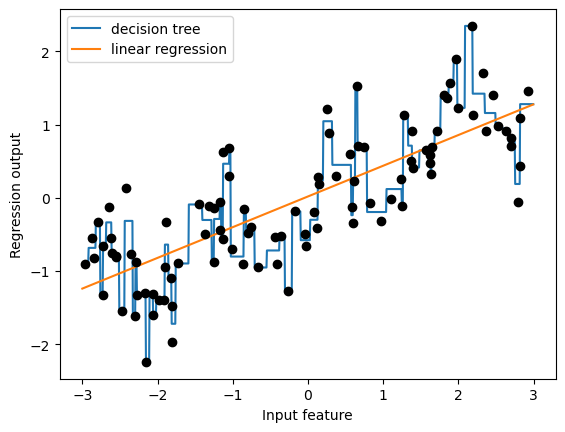

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import numpy as np


x, y = mglearn.datasets.make_wave(n_samples=100)
line = np.linspace(-3, 3, 1000, endpoint=False).reshape(-1, 1)
reg  = DecisionTreeRegressor(min_samples_split=3).fit(x, y)
plt.plot(line, reg.predict(line), label="decision tree")
reg  = LinearRegression().fit(x, y)
plt.plot(line, reg.predict(line), label="linear regression")
plt.plot(x[:, 0], y, 'o', c='k')
plt.ylabel("Regression output")
plt.xlabel("Input feature")
plt.legend(loc="best")

In [11]:
# illustrate the fabricated bins
bins = np.linspace(-3, 3, 11)
print(bins)

[-3.  -2.4 -1.8 -1.2 -0.6  0.   0.6  1.2  1.8  2.4  3. ]


In [12]:
# record for each data point which bin it falls into
which_bin = np.digitize(x, bins = bins)
print(x[:5])
print(which_bin[:5])

[[-0.75275929]
 [ 2.70428584]
 [ 1.39196365]
 [ 0.59195091]
 [-2.06388816]]
[[ 4]
 [10]
 [ 8]
 [ 6]
 [ 2]]


In [13]:
# another manual way of encoding
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse=False)
encoder.fit(which_bin) # find unique values
xbinned = encoder.transform(which_bin)
print(xbinned[:5])
print(xbinned.shape) # 10 features now because we specified 10 bins

[[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]
(100, 10)


Text(0.5, 0, 'Input feature')

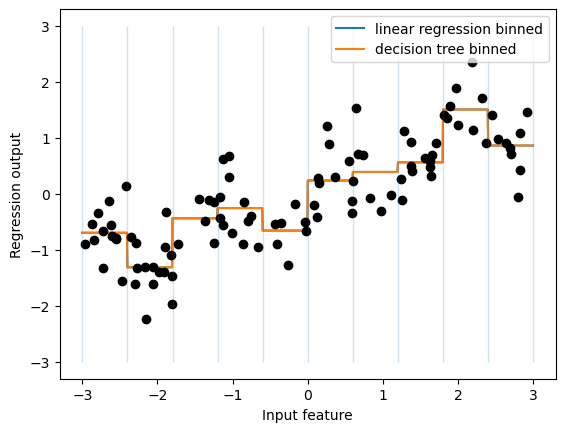

In [14]:
line_binned = encoder.transform(np.digitize(line, bins=bins))
reg         = LinearRegression().fit(xbinned, y)
plt.plot(line, reg.predict(line_binned), label='linear regression binned')
reg = DecisionTreeRegressor(min_samples_split=3).fit(xbinned, y)
plt.plot(line, reg.predict(line_binned), label='decision tree binned')
plt.plot(x[:, 0], y, 'o', c='k')
plt.vlines(bins, -3, 3, linewidth=1, alpha=.2)
plt.legend(loc="best")
plt.ylabel("Regression output")
plt.xlabel("Input feature")

The linear & decision tree lines are exactly on top of each other, meaning they are predicting the same thing. Tree based methods do not benefit much from binning but in this case, the linear regression method did benefit

## Interactions & Polynomials
Adding interaction features & polynomial features to the original data is common.

(100, 11)


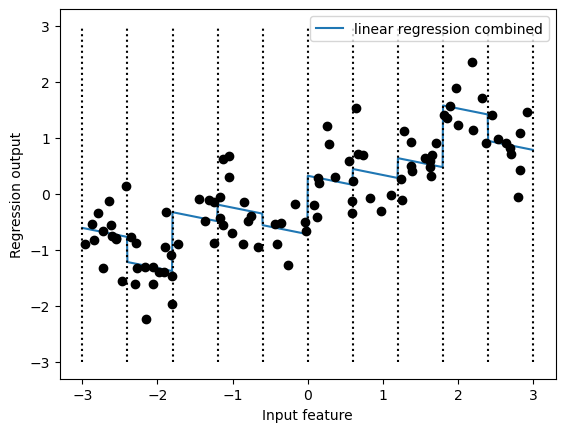

In [15]:
xcombined = np.hstack([x, xbinned])
print(xcombined.shape)

reg           = LinearRegression().fit(xcombined, y)
line_combined = np.hstack([line, line_binned])

plt.plot(line, reg.predict(line_combined), label='linear regression combined')
for bin in bins:
    plt.plot([bin, bin], [-3, 3], ':', c='k')
plt.legend(loc="best")
plt.ylabel("Regression output")
plt.xlabel("Input feature")
plt.plot(x[:, 0], y, 'o', c='k')


In the above, there is a shared slope across all the bins, which isn't too helpful. We can add an interaction term to give each bin their own slope

(100, 20)


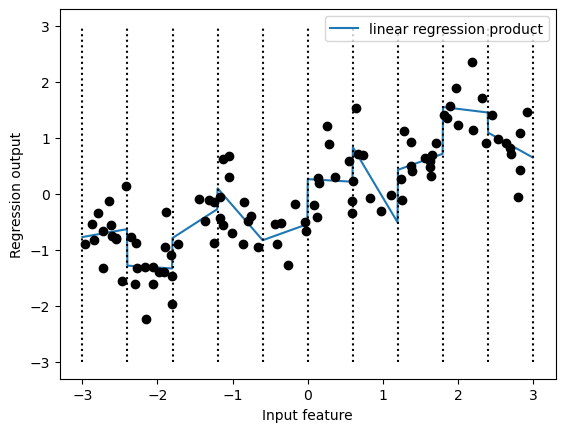

In [16]:
xproduct = np.hstack([xbinned, x * xbinned])
print(xproduct.shape)

reg          = LinearRegression().fit(xproduct, y)
line_product = np.hstack([line_binned, line * line_binned])

plt.plot(line, reg.predict(line_product), label='linear regression product')

for bin in bins:
    plt.plot([bin, bin], [-3, 3], ':', c='k')
plt.plot(x[:, 0], y, 'o', c='k')
plt.ylabel("Regression output")
plt.xlabel("Input feature")
plt.legend(loc="best")

Another way to augment our data is by adding a *polynomial* of the original feature values. These features are scores such as *x^2*, *x^3*, or *x^4*.

In [17]:
from sklearn.preprocessing import PolynomialFeatures

# include polynomials up to x^10
poly  = PolynomialFeatures(degree=10, include_bias=False)
poly.fit(x)
xpoly = poly.transform(x)
print(xpoly.shape)
print(x[:5])
print(xpoly[:5])
print(poly.get_feature_names_out())

(100, 10)
[[-0.75275929]
 [ 2.70428584]
 [ 1.39196365]
 [ 0.59195091]
 [-2.06388816]]
[[-7.52759287e-01  5.66646544e-01 -4.26548448e-01  3.21088306e-01
  -2.41702204e-01  1.81943579e-01 -1.36959719e-01  1.03097700e-01
  -7.76077513e-02  5.84199555e-02]
 [ 2.70428584e+00  7.31316190e+00  1.97768801e+01  5.34823369e+01
   1.44631526e+02  3.91124988e+02  1.05771377e+03  2.86036036e+03
   7.73523202e+03  2.09182784e+04]
 [ 1.39196365e+00  1.93756281e+00  2.69701700e+00  3.75414962e+00
   5.22563982e+00  7.27390068e+00  1.01250053e+01  1.40936394e+01
   1.96178338e+01  2.73073115e+01]
 [ 5.91950905e-01  3.50405874e-01  2.07423074e-01  1.22784277e-01
   7.26822637e-02  4.30243318e-02  2.54682921e-02  1.50759786e-02
   8.92423917e-03  5.28271146e-03]
 [-2.06388816e+00  4.25963433e+00 -8.79140884e+00  1.81444846e+01
  -3.74481869e+01  7.72888694e+01 -1.59515582e+02  3.29222321e+02
  -6.79478050e+02  1.40236670e+03]]
['x0' 'x0^2' 'x0^3' 'x0^4' 'x0^5' 'x0^6' 'x0^7' 'x0^8' 'x0^9' 'x0^10']


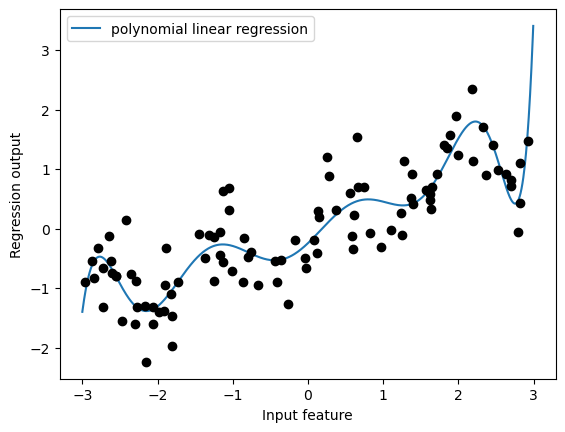

In [18]:
# do linear regression with the polynomial terms
reg       = LinearRegression().fit(xpoly, y)
line_poly = poly.transform(line)
plt.plot(line, reg.predict(line_poly), label='polynomial linear regression')
plt.plot(x[:, 0], y, 'o', c='k')
plt.ylabel("Regression output")
plt.xlabel("Input feature")
plt.legend(loc="best")

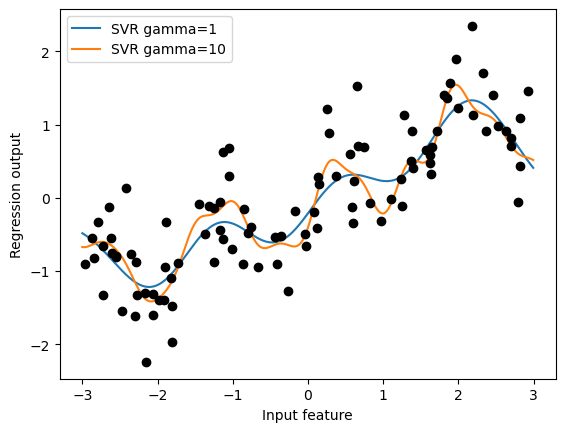

In [19]:
# we can compare this with a kernel SVM
from sklearn.svm import SVR

for gamma in [1, 10]:
    svr = SVR(gamma=gamma).fit(x, y)
    plt.plot(line, svr.predict(line), label='SVR gamma={}'.format(gamma))

plt.plot(x[:, 0], y, 'o', c='k')
plt.ylabel("Regression output")
plt.xlabel("Input feature")
plt.legend(loc="best")

In [20]:
# now use a more realistic data set
from sklearn.datasets import load_boston
from sklearn.preprocessing import MinMaxScaler

# boston = load_boston()
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df   = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data     = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target   = raw_df.values[1::2, 2]

xtrain, xtest, ytrain, ytest = train_test_split(data, target, random_state=0)

# rescale data
scaler        = MinMaxScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled  = scaler.transform(xtest)

In [21]:
# create polynomial features
poly        = PolynomialFeatures(degree=2).fit(xtrain_scaled)
xtrain_poly = poly.transform(xtrain_scaled)
xtest_poly  = poly.transform(xtest_scaled)

print("X_train.shape: {}".format(xtrain.shape))
print("X_train_poly.shape: {}".format(xtrain_poly.shape))

X_train.shape: (379, 13)
X_train_poly.shape: (379, 105)


In [22]:
# constructing interaction terms in a different data set
from sklearn.linear_model import Ridge

ridge = Ridge().fit(xtrain_scaled, ytrain)
print(ridge.score(xtest_scaled, ytest))
ridge = Ridge().fit(xtrain_poly, ytrain)
print(ridge.score(xtest_poly, ytest)) # noticable improvement

0.6214583227921032
0.7534782020980574


In [23]:
# what about using a random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100).fit(xtrain_scaled, ytrain)
print(rf.score(xtest_scaled, ytest))
rf = RandomForestRegressor(n_estimators=100).fit(xtrain_poly, ytrain)
print(rf.score(xtest_poly, ytest)) # we did worse but still better than the ridge algorithm

0.7881485004888202
0.7836190286972359


## Univariate Nonlinear Transformations

Most models work best when each feature (and in regression also the target) is loosely Gaussian distributed. Using transformations like `log` or `exp` is a hacky but simple and efficient way to achieve this

In [24]:
# demonstrate log transforming int types
rnd   = np.random.RandomState(0)
x_org = rnd.normal(size=(1000,3))
w     = rnd.normal(3)
x     = rnd.poisson(10 * np.exp(x_org))
y     = np.dot(x_org, w)
print(np.bincount(x[:, 0]))

[26 40 55 51 65 58 45 62 43 35 42 33 39 27 23 24 25 20 21 25 22 15 11 12
 10  9  8  7  8 10  5  7  4  7  3  6  4  5  6  4  3  3  1  3  6  1  3  3
  3  2  3  4  2  0  3  3  0  2  0  1  0  1  0  3  2  0  1  0  2  0  1  0
  1  3  0  2  2  0  0  0  0  0  2  1  1  1  0  0  1  0  0  0  1  0  0  0
  1  0  0  0  0  0  0  0  1  0  0  0  1  1  1  0  0  0  0  0  0  0  1  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  1]


Text(0.5, 0, 'Value')

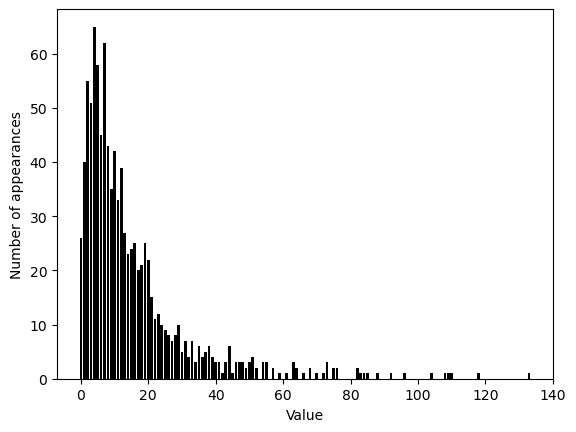

In [25]:
# visualize
bins = np.bincount(x[:, 0])
plt.bar(range(len(bins)), bins, color='black')
plt.ylabel("Number of appearances")
plt.xlabel("Value")

In [26]:
# illustrate how linear models fail for this kind of distribution of data
xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state=0)
score = Ridge().fit(xtrain, ytrain).score(xtest, ytest)
print("Test score: {:.3f}".format(score))

Test score: 0.618


Test score: 0.861


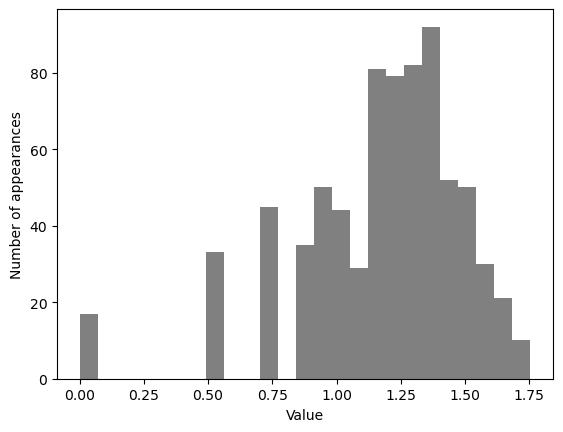

In [27]:
# transform
xtrain_log = np.log(xtrain + 1) # to avoid 0 counts
xtest_log  = np.log(xtest + 1)
plt.hist(np.log(xtrain_log[:, 0] + 1), bins=25, color='gray')
plt.ylabel("Number of appearances")
plt.xlabel("Value")

score = Ridge().fit(xtrain_log, ytrain).score(xtest_log, ytest)
print("Test score: {:.3f}".format(score))

## Automatic Feature Selection
There are three basic strategies for reducing the number of features to the most informative ones: **univariate statistics**, **model-based selection**, and **iterative selection**.

In **univariate statistics**, we compute whether there is a statistically significant relationship between each feature and the target. The features that are related with the highest confidence are selected. In the case of classification, this is also known as **analysis of variance (ANOVA)**. They are called univariate because they only consider each feature individually. Consequently, a feature will be discarded if it only informative when combined with another feature.

In [28]:
# applying univariate feature selection
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import SelectPercentile

# we will add noise to the dataset for demonstration
cancer   = load_breast_cancer()
rng      = np.random.RandomState(42)
noise    = rng.normal(size=(len(cancer.data), 50))
xw_noise = np.hstack([cancer.data, noise])
xtrain, xtest, ytrain, ytest = train_test_split(xw_noise, cancer.target, random_state=0, test_size=.5)

# use default f_classif test for classification
select = SelectPercentile(percentile=50) # select 50% of features
select.fit(xtrain, ytrain)
xtrain_selected = select.transform(xtrain)

print("X_train.shape: {}".format(xtrain.shape))
print("X_train_selected.shape: {}".format(xtrain_selected.shape)) # we went from 80 to 40 features

X_train.shape: (284, 80)
X_train_selected.shape: (284, 40)


[ True  True  True  True  True  True  True  True  True False  True False
  True  True  True  True  True  True False False  True  True  True  True
  True  True  True  True  True  True False False False  True False  True
 False False  True False False False False  True False False  True False
 False  True False  True False False False False False False  True False
  True False False False False  True False  True False False False False
  True  True False  True False False False False]


Text(0.5, 0, 'Sample index')

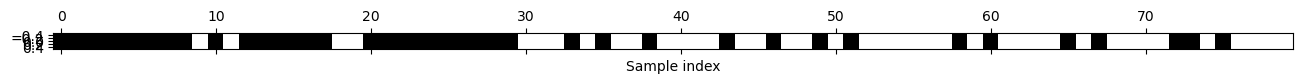

In [29]:
# see which features were kept
mask = select.get_support()
print(mask)

# visualize the mask (black if true, white if false)
plt.matshow(mask.reshape(1, -1), cmap = "gray_r")
plt.xlabel("Sample index") # most noise is removed (right side)

In [30]:
# try it on a log scale
xtest_selected = select.transform(xtest)
lr             = LinearRegression()
lr.fit(xtrain, ytrain)

print(lr.score(xtest, ytest))
lr.fit(xtrain_selected, ytrain)
print(lr.score(xtest_selected, ytest))

0.6171501685488077
0.7177219962621244


## Model-Based Feature Selection
**Model-based feature selection** uses a supervised machine learning model to judge the importance of each feature, and keeps only the most important ones. The supervised model that is used for feature selection doesn't need to be the same model that is used for the final supervised modeling.

Decision trees and decision tree-based models provide feature importance attributes, which direcly encodes the importance of each feature. Linear models have coefficients, which can also be used to capture feature importances by considering the absolute values. Also, unlike univariate selection, model-based selection considers all features at once, and so it can capture interactions (if the model can capture them)

In [ ]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

# we need to create an ensembl that can do the selecting and embed the underlying model
select = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), threshold = "median") 
select.fit(xtrain, ytrain)
xtrain_l1 = select.transform(xtrain)
print(xtrain.shape, xtrain_l1.shape) # select half

(284, 80) (284, 40)


Text(0.5, 0, 'Sample index')

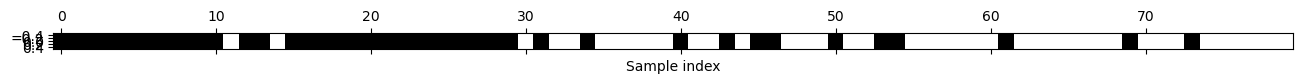

In [ ]:
# visualize what was kept
mask = select.get_support()
plt.matshow(mask.reshape(1,-1), cmap='gray_r')
plt.xlabel("Sample index") # all but two of the original features were kept

In [37]:
xtest_l1 = select.transform(xtest)
score    = LogisticRegression().fit(xtrain_l1, ytrain).score(xtest_l1, ytest)
print(score)

0.9298245614035088


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Iterative Feature Selection
In **iterative feature selection**, a series of models are built, with varying numbers of features. There are two basic methods:
  - Starting with no features and adding features 1 by 1 until some stopping criterion is reached
  - Starting with all features and removing features 1 by 1 until some stopping criterion is reached

Because a series of models are built, these methods are much more computationallly expensive than the methods we discussed previously. One method is called the **recursive feature elimination (RFE)** method, which builds a model, discards the least important feature according to the model, builds a new model without the discarded features, and continues the process until only a prespecified number of features are left. 

Text(0.5, 0, 'Sample index')

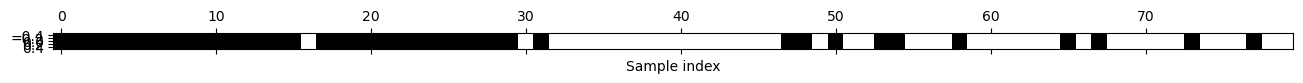

In [ ]:
from sklearn.feature_selection import RFE

# 40 is half the samples
select = RFE(RandomForestClassifier(n_estimators=100, random_state=42), n_features_to_select=40)
select.fit(xtrain, ytrain)
mask   = select.get_support()
plt.matshow(mask.reshape(1,-1), cmap='gray_r')
plt.xlabel("Sample index") # all but two of the original features were kept


In [42]:
xtrain_rfe = select.transform(xtrain)
xtest_rfe  = select.transform(xtest)
score      = LogisticRegression().fit(xtrain_rfe, ytrain).score(xtest_rfe, ytest)
print(select.score(xtest, ytest)) # on the full test data
print(score)

0.9508771929824561
0.9298245614035088


/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Utilizing Expert Knowledge
Expert knowledge can help build models. That's the point of this section

In [44]:
citibike = mglearn.datasets.load_citibike()
print(citibike.head())

starttime
2015-08-01 00:00:00     3
2015-08-01 03:00:00     0
2015-08-01 06:00:00     9
2015-08-01 09:00:00    41
2015-08-01 12:00:00    39
Freq: 3H, Name: one, dtype: int64


/Users/giovannimadrigal/Library/CloudStorage/Dropbox/Personal/Other/intro.to.ml/intro.to.ml.github/../introduction_to_ml_with_python/mglearn/datasets.py:57: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  data_resampled = data_starttime.resample("3h").sum().fillna(0)


Text(0, 0.5, 'Rentals')

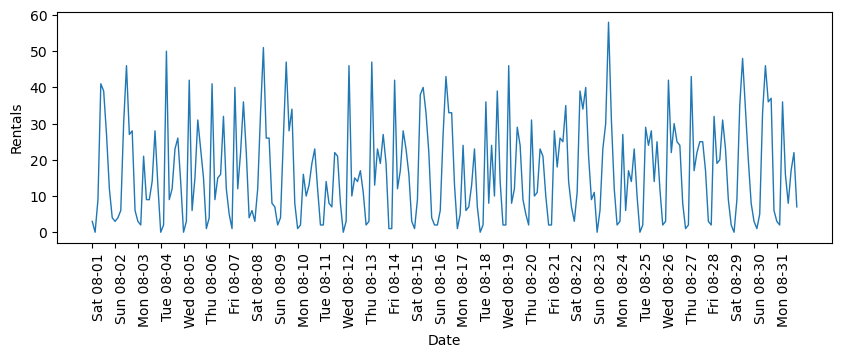

In [45]:
# visualize
plt.figure(figsize=(10, 3))
xticks = pd.date_range(start=citibike.index.min(), end=citibike.index.max(), freq='D')
plt.xticks(xticks, xticks.strftime("%a %m-%d"), rotation=90, ha="left")
plt.plot(citibike, linewidth=1)
plt.xlabel("Date")
plt.ylabel("Rentals")

In [49]:
# What we want to do is LEARN FROM THE PAST AND PREDICT FOR THE FUTURE
y = citibike.values # number of rentals
x = citibike.index.strftime("%s").astype("int").values.reshape(-1, 1) # get time, just doing some conversion

In [50]:
# use the first 184 points for training
n_train = 184

# function to evaluate and plot a regressor on a given feature set
def eval_on_features(features, target, regressor):
    xtrain, xtest = features[:n_train], features[n_train:]
    ytrain, ytest = target[:n_train], target[n_train:]
    regressor.fit(xtrain, ytrain)
    print("Test-set R^2: {:.2f}".format(regressor.score(xtest, ytest)))
    ypred       = regressor.predict(xtest)
    ypred_train = regressor.predict(xtrain)
    plt.figure(figsize=(10, 3))
    plt.xticks(range(0, len(x), 8), xticks.strftime("%a %m-%d"), rotation=90, ha="left")
    plt.plot(range(n_train), ytrain, label="train")
    plt.plot(range(n_train, len(ytest) + n_train), ytest, '-', label="test")
    plt.plot(range(n_train), ypred_train, '--' , label="prediction train")
    plt.plot(range(n_train, len(ytest) + n_train), ypred, label="prediction test")
    plt.legend(loc=(1.01, 0))
    plt.xlabel("Date")
    plt.ylabel("Rentals")

Test-set R^2: -0.04


<Figure size 640x480 with 0 Axes>

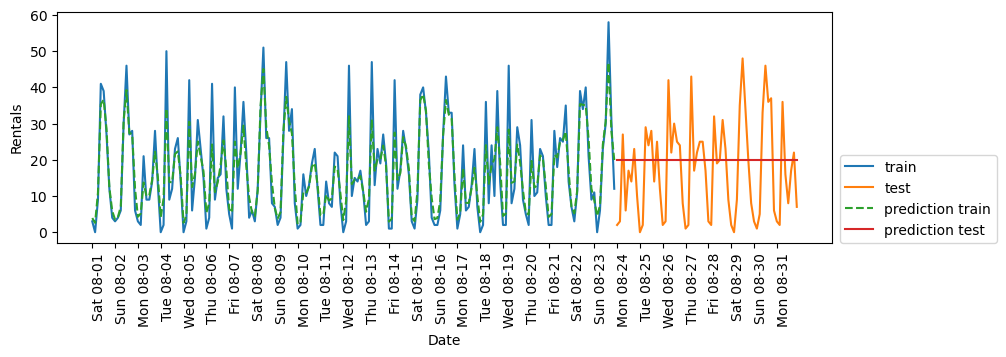

In [51]:
# plot

regressor = RandomForestRegressor(n_estimators=100, random_state=0)
plt.figure()
eval_on_features(x, y, regressor)

A prediction test of a flat line clearly shows our model is terrible despite doing well on the train dataset. Given that the model hasn't seen times in the future, it will be a terrible predictor. Trees & random forests cannot *extraplolate* to feature ranges outside the training set.

Test-set R^2: 0.60


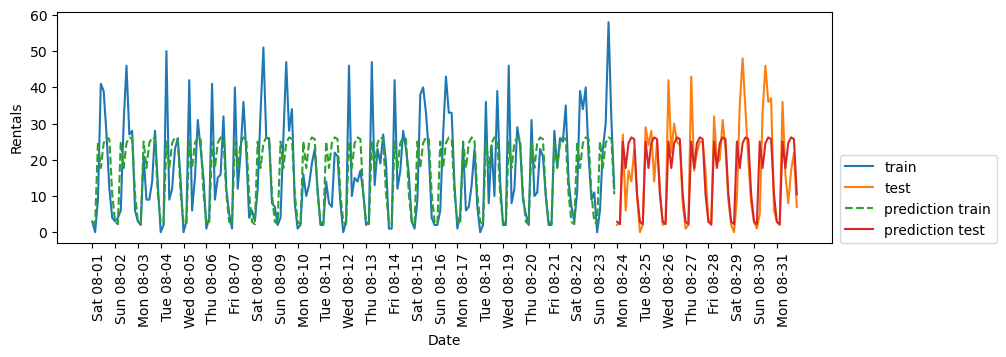

In [53]:
# add new information / expert knowledge
xhour = citibike.index.hour.values.reshape(-1, 1)
eval_on_features(xhour, y , regressor)

Test-set R^2: 0.84


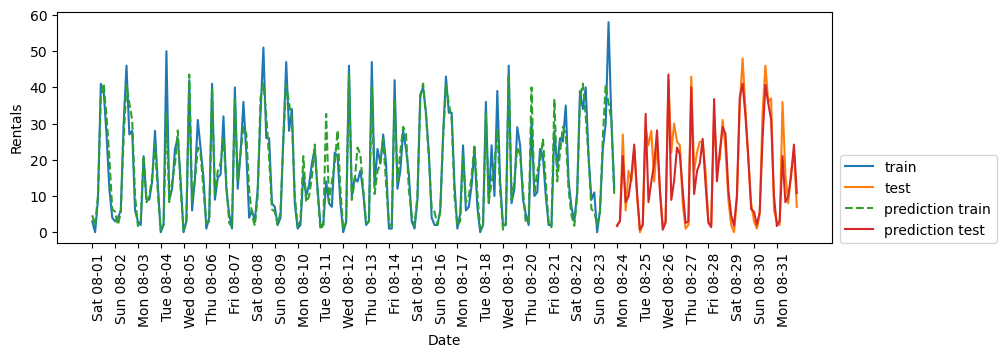

In [54]:
# let's add the day of the week 
xhour_week = np.hstack([citibike.index.dayofweek.values.reshape(-1, 1), citibike.index.hour.values.reshape(-1, 1)])
eval_on_features(xhour_week, y, regressor)

Test-set R^2: 0.13


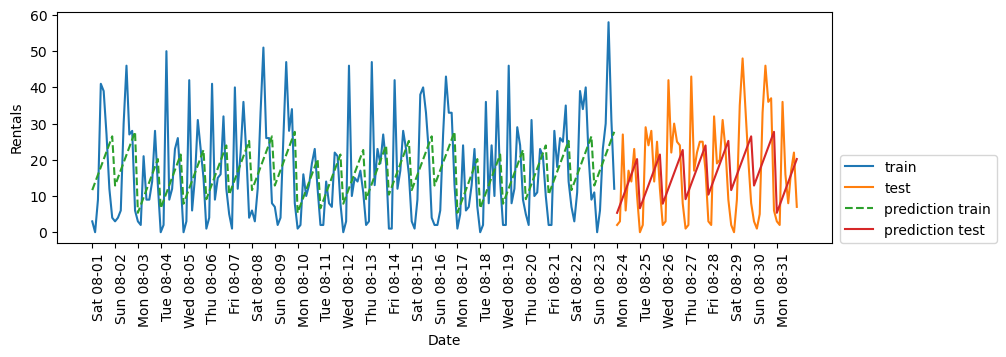

In [55]:
# using a similar model since the idea is simple
eval_on_features(xhour_week, y, LinearRegression())

Test-set R^2: 0.62


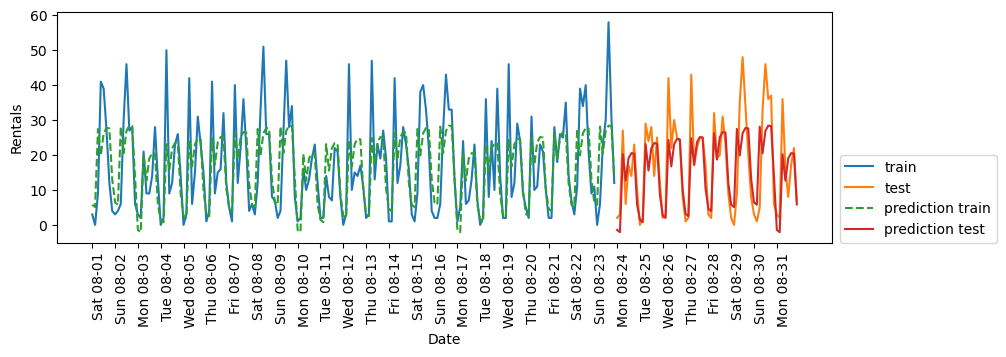

In [59]:
# transform the times to categorical values
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder()
xhour_week_onehot = enc.fit_transform(xhour_week).toarray()
eval_on_features(xhour_week_onehot, y, Ridge())

Test-set R^2: 0.85


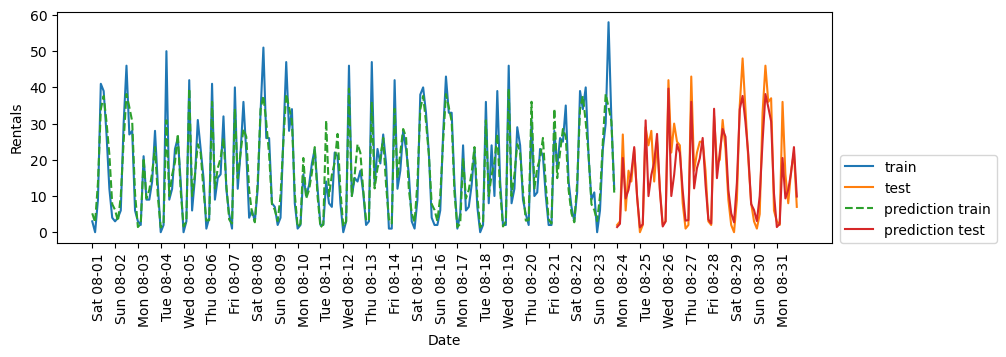

In [60]:
# add an interaction term
poly_transform         = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
xhour_week_onehot_poly = poly_transform.fit_transform(xhour_week_onehot)
lr                     = Ridge()
eval_on_features(xhour_week_onehot_poly, y, lr)

This model is comparable to the random forest, however, a big benefit of this model is that it is very clear what is learned: one coefficient for each day and time

/Users/giovannimadrigal/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


Text(0, 0.5, 'Feature')

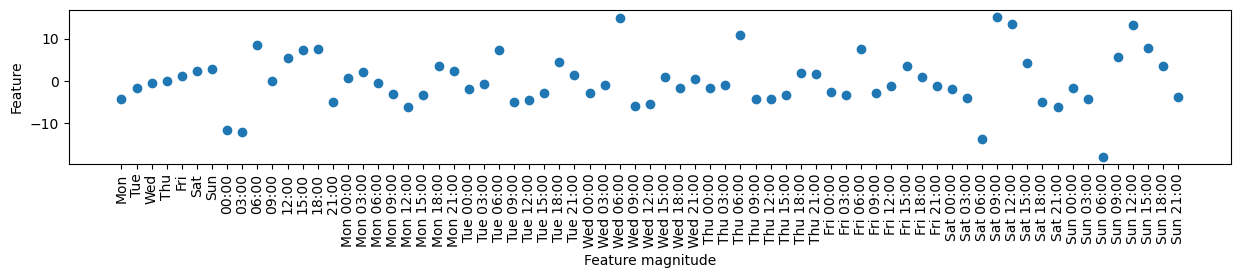

In [61]:
# see coeffients
hour             = ["%02d:00" % i for i in range(0, 24, 3)]
day              = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
features         = day + hour
features_poly    = poly_transform.get_feature_names(features)
features_nonzero = np.array(features_poly)[lr.coef_ != 0]
coef_nonzero     = lr.coef_[lr.coef_ != 0]

plt.figure(figsize=(15, 2))
plt.plot(coef_nonzero, 'o')
plt.xticks(np.arange(len(coef_nonzero)), features_nonzero, rotation=90)
plt.xlabel("Feature magnitude")
plt.ylabel("Feature")